In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [24]:
VIT_PATH  = "/content/drive/MyDrive/morph_project/models/vit_advanced.pth"

EFF_PATH  = "/content/drive/MyDrive/morph_project/models/efficientnet_b3_tuned_baseline.pth"

CONV_PATH = "/content/drive/MyDrive/morph_project/models/convnextv2_best_224_finetuned.pth"

SWIN_PATH = "/content/drive/MyDrive/morph_project/swin224_recall_tuned.pth"


In [25]:
import os

for p in [VIT_PATH, SWIN_PATH, EFF_PATH, CONV_PATH]:
    print(p, "->", os.path.exists(p))


/content/drive/MyDrive/morph_project/models/vit_advanced.pth -> True
/content/drive/MyDrive/morph_project/swin224_recall_tuned.pth -> True
/content/drive/MyDrive/morph_project/models/efficientnet_b3_tuned_baseline.pth -> True
/content/drive/MyDrive/morph_project/models/convnextv2_best_224_finetuned.pth -> True


In [26]:
import timm
import torch.nn as nn


In [27]:
vit_model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=2
)


In [30]:
swin_model = timm.create_model(
    "swin_base_patch4_window7_224",
    pretrained=False,
    num_classes=2
)


In [28]:
eff_model = timm.create_model(
    "efficientnet_b3",
    pretrained=False,
    num_classes=2
)


In [35]:
conv_model = timm.create_model(
    "convnextv2_tiny",
    pretrained=False,
    num_classes=2
)


In [39]:
conv_ckpt = torch.load(CONV_PATH, map_location=device)

new_conv_state_dict = {
    k.replace("backbone.", ""): v
    for k, v in conv_ckpt.items()
    if k.startswith("backbone.")
}


In [40]:
missing, unexpected = conv_model.load_state_dict(
    new_conv_state_dict,
    strict=False
)

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)


Missing keys: ['head.fc.weight', 'head.fc.bias']
Unexpected keys: []


In [41]:
conv_model.to(device).eval()


ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): GlobalResponseNormMlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (grn): GlobalResponseNorm()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), 

In [42]:
x = torch.randn(1, 3, 224, 224).to(device)
print(conv_model(x).shape)


torch.Size([1, 2])


In [44]:
print("ViT model:", vit_model is not None)
print("EfficientNet model:", eff_model is not None)
print("ConvNeXt model:", conv_model is not None)
print("Swin model:", swin_model is not None)


ViT model: True
EfficientNet model: True
ConvNeXt model: True
Swin model: True


In [45]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print("ViT params:", count_params(vit_model))
print("EfficientNet params:", count_params(eff_model))
print("ConvNeXt params:", count_params(conv_model))
print("Swin params:", count_params(swin_model))


ViT params: 85800194
EfficientNet params: 10699306
ConvNeXt params: 27868034
Swin params: 86745274


In [47]:
vit_model  = vit_model.to(device)
eff_model  = eff_model.to(device)
conv_model = conv_model.to(device)
swin_model = swin_model.to(device)


In [48]:
vit_model.eval()
eff_model.eval()
conv_model.eval()
swin_model.eval()


SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=128, out_features=384, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=128, out_features=128, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=128, out_features=512, bias=True)
            (act): GELU(approximate='none')
            (

In [49]:
import torch

x = torch.randn(1, 3, 224, 224).to(device)

with torch.no_grad():
    out_vit  = vit_model(x)
    out_eff  = eff_model(x)
    out_conv = conv_model(x)
    out_swin = swin_model(x)

print("ViT output shape:", out_vit.shape)
print("EffNet output shape:", out_eff.shape)
print("ConvNeXt output shape:", out_conv.shape)
print("Swin output shape:", out_swin.shape)


ViT output shape: torch.Size([1, 2])
EffNet output shape: torch.Size([1, 2])
ConvNeXt output shape: torch.Size([1, 2])
Swin output shape: torch.Size([1, 2])


In [50]:
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [51]:
def preprocess_image(image_path, device):
    img = Image.open(image_path).convert("RGB")
    img = inference_transform(img)
    img = img.unsqueeze(0)  # [1, 3, 224, 224]
    return img.to(device)


In [52]:
@torch.no_grad()
def get_probabilities(model, x):
    logits = model(x)
    probs = F.softmax(logits, dim=1)
    return probs.squeeze(0).cpu().numpy()  # shape: [2]


In [53]:
SOFT_VOTING_WEIGHTS = {
    "vit": 0.25,
    "eff": 0.25,
    "conv": 0.25,
    "swin": 0.25
}


In [54]:
def soft_voting_inference(image_path, device):
    x = preprocess_image(image_path, device)

    p_vit  = get_probabilities(vit_model, x)
    p_eff  = get_probabilities(eff_model, x)
    p_conv = get_probabilities(conv_model, x)
    p_swin = get_probabilities(swin_model, x)

    fused_probs = (
        SOFT_VOTING_WEIGHTS["vit"]  * p_vit +
        SOFT_VOTING_WEIGHTS["eff"]  * p_eff +
        SOFT_VOTING_WEIGHTS["conv"] * p_conv +
        SOFT_VOTING_WEIGHTS["swin"] * p_swin
    )

    pred_class = int(np.argmax(fused_probs))
    confidence = float(fused_probs[pred_class])

    label_map = {0: "Licit", 1: "Illicit"}

    return {
        "final_prediction": label_map[pred_class],
        "final_confidence": confidence,
        "fused_probabilities": fused_probs,
        "individual_model_probabilities": {
            "ViT": p_vit,
            "EfficientNet-B3": p_eff,
            "ConvNeXtV2-Tiny": p_conv,
            "Swin-Tiny": p_swin
        }
    }


In [57]:
image_path = "/content/drive/MyDrive/morph_project/casias2.png"  # change this

result = soft_voting_inference(image_path, device)

print("Final Prediction:", result["final_prediction"])
print("Final Confidence:", result["final_confidence"])

print("\nIndividual Model Probabilities:")
for model, prob in result["individual_model_probabilities"].items():
    print(model, prob)

print("\nFused Probabilities:", result["fused_probabilities"])


Final Prediction: Illicit
Final Confidence: 0.6432587504386902

Individual Model Probabilities:
ViT [0.26907855 0.73092145]
EfficientNet-B3 [0.00374343 0.9962566 ]
ConvNeXtV2-Tiny [0.6073107 0.3926893]
Swin-Tiny [0.5468324  0.45316765]

Fused Probabilities: [0.35674125 0.64325875]


In [58]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


In [59]:
import os

TEST_DIR = "/content/drive/MyDrive/morph_project"

for root, dirs, files in os.walk(TEST_DIR):
    print(root)
    for d in dirs:
        print("  📁", d)
    for f in files[:5]:
        print("   -", f)
    print("-" * 40)


/content/drive/MyDrive/morph_project
  📁 datasets
  📁 models
  📁 extracted_datasets
  📁 extracted
  📁 processed
  📁 processed_new
  📁 fusion
  📁 plots
  📁 preprocessing_figures
   - efficientnet_b3_casia.pth
   - swinv2_best.pth
   - swinv2_train_acc.npy
   - swinv2_val_acc.npy
   - swinv2_train_loss.npy
----------------------------------------
/content/drive/MyDrive/morph_project/datasets
   - archive (1).zip
   - deepfake.zip
----------------------------------------
/content/drive/MyDrive/morph_project/models
   - vit_casia.pth
   - rf_lbp_model.pkl
   - rf_lbp_model_v2.pkl
   - vit_hdf5.pth
   - svm_hog_model.pkl
----------------------------------------
/content/drive/MyDrive/morph_project/extracted_datasets
  📁 CASIA2
----------------------------------------
/content/drive/MyDrive/morph_project/extracted_datasets/CASIA2
  📁 Au
  📁 CASIA 2 Groundtruth
  📁 Tp
----------------------------------------
/content/drive/MyDrive/morph_project/extracted_datasets/CASIA2/Au
   - Au_sec_10001.j

In [60]:
import os
import random

CASIA_PATH = "/content/drive/MyDrive/morph_project/extracted_datasets/CASIA2"

au_dir = os.path.join(CASIA_PATH, "Au")
tp_dir = os.path.join(CASIA_PATH, "Tp")

au_images = [os.path.join(au_dir, f) for f in os.listdir(au_dir)]
tp_images = [os.path.join(tp_dir, f) for f in os.listdir(tp_dir)]

print("Total Authentic (Au):", len(au_images))
print("Total Tampered (Tp):", len(tp_images))


Total Authentic (Au): 7492
Total Tampered (Tp): 1554


In [62]:
random.seed(42)

test_ratio = 0.2

test_au = random.sample(au_images, int(len(au_images) * test_ratio))
test_tp = random.sample(tp_images, int(len(tp_images) * test_ratio))

print("Test Authentic:", len(test_au))
print("Test Tampered:", len(test_tp))


Test Authentic: 1498
Test Tampered: 310


In [65]:
import torch.nn.functional as F

@torch.no_grad()
def soft_voting_probs(x):
    """
    x: tensor of shape [1, 3, 224, 224]
    returns: numpy array of shape [2] -> [P(licit), P(illicit)]
    """

    p_vit  = F.softmax(vit_model(x), dim=1)
    p_eff  = F.softmax(eff_model(x), dim=1)
    p_conv = F.softmax(conv_model(x), dim=1)
    p_swin = F.softmax(swin_model(x), dim=1)

    fused = (
        0.25 * p_vit +
        0.25 * p_eff +
        0.25 * p_conv +
        0.25 * p_swin
    )

    return fused.squeeze(0).cpu().numpy()


In [66]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_true = []
y_pred = []
y_scores = []

# Authentic images (label = 0)
for img_path in tqdm(test_au, desc="Evaluating Authentic"):
    x = preprocess_image(img_path, device)
    probs = soft_voting_probs(x)

    y_true.append(0)
    y_pred.append(probs.argmax())
    y_scores.append(probs[1])  # illicit prob

# Tampered images (label = 1)
for img_path in tqdm(test_tp, desc="Evaluating Tampered"):
    x = preprocess_image(img_path, device)
    probs = soft_voting_probs(x)

    y_true.append(1)
    y_pred.append(probs.argmax())
    y_scores.append(probs[1])


Evaluating Tampered: 100%|██████████| 310/310 [03:13<00:00,  1.60it/s]


In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)
roc_auc   = roc_auc_score(y_true, y_scores)
cm        = confusion_matrix(y_true, y_pred)

print("\n📊 Soft Voting (Uniform Weights) – CASIA2 Test Results\n")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}  ← Illicit detection")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("\nConfusion Matrix:\n", cm)



📊 Soft Voting (Uniform Weights) – CASIA2 Test Results

Accuracy  : 0.6748
Precision : 0.3227
Recall    : 0.8161  ← Illicit detection
F1-score  : 0.4625
ROC-AUC   : 0.8523

Confusion Matrix:
 [[967 531]
 [ 57 253]]


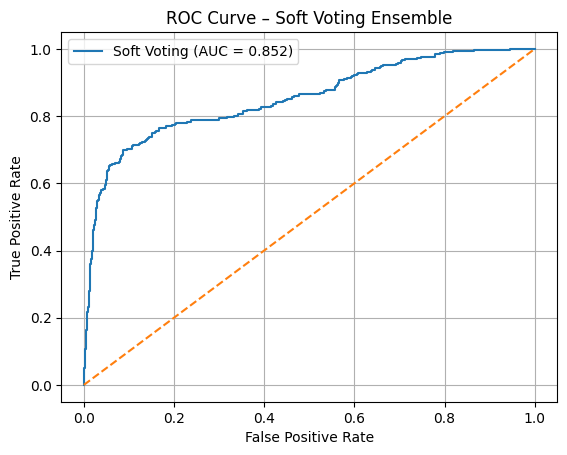

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Soft Voting (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Soft Voting Ensemble")
plt.legend()
plt.grid(True)
plt.show()


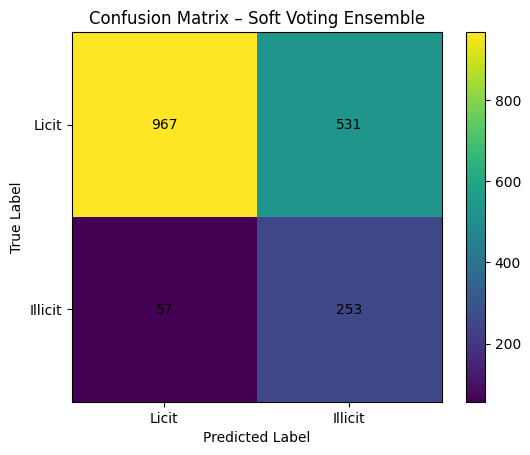

In [69]:
import numpy as np

cm = np.array([[967, 531],
               [57, 253]])

plt.figure()
plt.imshow(cm)
plt.colorbar()

plt.xticks([0, 1], ["Licit", "Illicit"])
plt.yticks([0, 1], ["Licit", "Illicit"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Soft Voting Ensemble")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


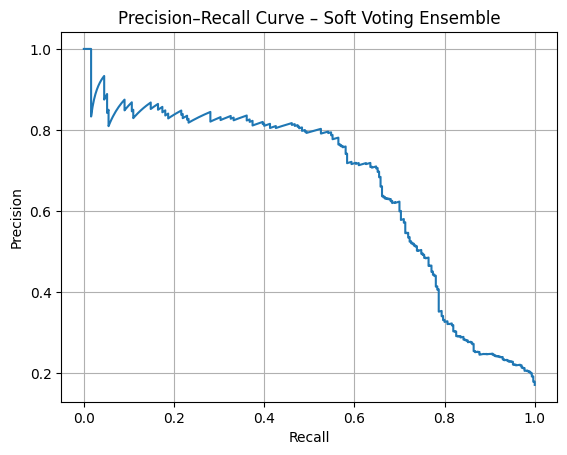

In [70]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_scores)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Soft Voting Ensemble")
plt.grid(True)
plt.show()


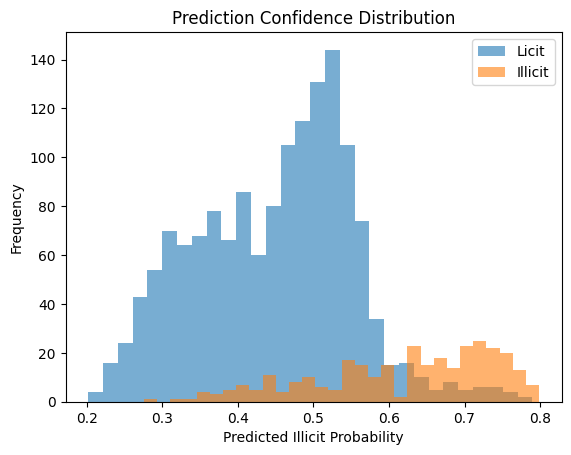

In [71]:
licit_scores = [s for s, y in zip(y_scores, y_true) if y == 0]
illicit_scores = [s for s, y in zip(y_scores, y_true) if y == 1]

plt.figure()
plt.hist(licit_scores, bins=30, alpha=0.6, label="Licit")
plt.hist(illicit_scores, bins=30, alpha=0.6, label="Illicit")
plt.xlabel("Predicted Illicit Probability")
plt.ylabel("Frequency")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.show()
